# Electricity Access Analysis for Sub-Saharan Africa

## Objective

The objective of this notebook is to analyze electricity electricity across Sub-Saharan African countries using World Bank data. The analysis explores historical trends, compares country performance, and develops a simple weighted priority model to identify countries that may warrant further electricity investment.

## Dataset

- Source: World Bank – World Development Indicators
- Indicator: Access to electricity (% of population)
- Years analyzed: 2014–2023

## Workflow

1. Load and inspect the data
2. Clean and prepare the dataset
3. Merge country metadata
4. Filter Sub-Saharan African countries
5. Perform exploratory data analysis (EDA)
6. Engineer new features
7. Build a weighted priority model
8. Perform sensitivity analysis
9. Visualize results

### project setup

In [33]:

from    pathlib import Path
import sys

# Add the project root to Python's path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



###  Import Libraries

In [34]:
import pandas as pd

from src.load_data import (
    load_worldbank_data,
    load_metadata,
)

from src.clean_data import (
    merge_metadata,
    filter_ssa,
    select_years,
)

from src.scoring import (
    calculate_access_improvement,
    calculate_relative_improvement,
    calculate_people_without_electricity,
    calculate_access_score,
    calculate_improvement_score,
    calculate_population_score,
    calculate_priority_score,
    calculate_priority_score_with_population,
)

from src.visualization import (
    plot_average_access,
    plot_improvement_scatter,
    plot_priority_ranking,
)

   ### Load data

In [35]:
electricity_df = load_worldbank_data(
    "../data/raw/electricity/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_3606.csv"
)

metadata = load_metadata(
    "../data/raw/electricity/Metadata_Country_API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_3606.csv"
)

### Inspect the dataset

In [36]:
# Number of rows and columns
print("Shape:", electricity_df.shape)

# Column names
print("\nColumns:")
print(electricity_df.columns.tolist())

Shape: (265, 71)

Columns:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [37]:
electricity_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    str    
 1   Country Code    265 non-null    str    
 2   Indicator Name  265 non-null    str    
 3   Indicator Code  265 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

In [38]:
electricity_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000,NaN,NaN,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.902228,51.338199,51.289374,51.851866,54.366012,55.683570,57.064737,NaN,NaN,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000,NaN,NaN,NaN


In [39]:
# Count missing values in each column
electricity_df.isna().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              265
                 ... 
2022                3
2023                3
2024              265
2025              265
Unnamed: 70       265
Length: 71, dtype: int64

In [40]:
electricity_df[electricity_df["2023"].isna()][["Country Name", "Country Code", "2023"]]

,Country Name,Country Code,2023
11,American Samoa,ASM,NaN
109,Not classified,INX,NaN
260,Kosovo,XKX,NaN


In [41]:
# Show all country names
electricity_df["Country Name"]

0                            Aruba
1      Africa Eastern and Southern
2                      Afghanistan
3       Africa Western and Central
4                           Angola
                  ...             
260                         Kosovo
261                    Yemen, Rep.
262                   South Africa
263                         Zambia
264                       Zimbabwe
Name: Country Name, Length: 265, dtype: str

### Clean Data

In [42]:
# Display unique country names alphabetically
sorted(electricity_df["Country Name"].unique())

['Afghanistan',
 'Africa Eastern and Southern',
 'Africa Western and Central',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Caribbean small states',
 'Cayman Islands',
 'Central African Republic',
 'Central Europe and the Baltics',
 'Chad',
 'Channel Islands',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Early-demographic dividend',
 'East

####    Merge Metadata

In [43]:
# Merge the electricity data with the country metadata
electricity_df_merged = merge_metadata(
    electricity_df,
    metadata
)

electricity_df_merged.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2022,2023,2024,2025,Unnamed: 70,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.900000,100.000000,NaN,NaN,NaN,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.801258,50.667516,NaN,NaN,NaN,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,85.300000,85.300000,NaN,NaN,NaN,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,55.683570,57.064737,NaN,NaN,NaN,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.500000,51.100000,NaN,NaN,NaN,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


####    Filter Sub-Saharan Africa

In [44]:
ssa_df = filter_ssa(electricity_df_merged)
ssa_df.shape

(48, 76)

### Exploratory Data Analysis


In [45]:
# Select only the years we want
years = select_years()

# Summary statistics
ssa_df[years].describe().round(2)

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,48.00,48.00,48.00,48.00,48.00,48.00,48.00,48.00,48.00,48.00
mean,41.78,42.82,45.23,46.45,49.03,49.87,51.20,52.77,53.91,56.14
std,25.72,25.26,24.90,24.78,24.27,25.08,25.06,25.12,24.97,25.02
min,4.30,4.80,5.30,4.20,6.30,6.80,7.30,7.70,8.40,5.40
25%,20.25,22.12,25.38,25.58,33.95,30.98,33.05,35.62,37.08,40.22
50%,35.10,40.55,42.70,44.15,47.00,47.80,50.25,50.05,51.80,56.05
75%,60.25,60.90,63.60,62.68,66.12,68.88,67.50,68.78,71.25,72.85
max,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


### Vizualization

This section calculates the average electricity electricity across all 48 Sub-Saharan African countries and visualizes the trend over time (2014–2023)

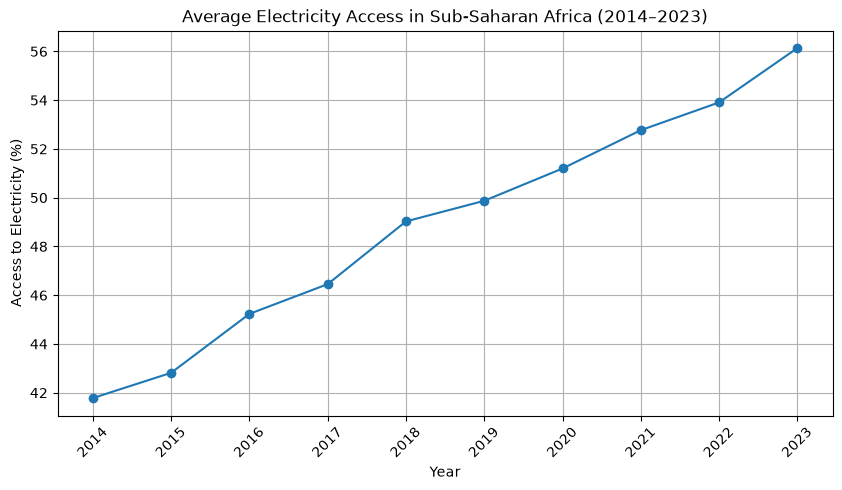

In [46]:
import matplotlib.pyplot as plt

# Calculate the average electricity electricity for each year
mean_electricity = ssa_df[years].mean()

plt.figure(figsize=(10, 5))
plt.plot(mean_electricity.index, mean_electricity.values, marker="o")

plt.title("Average Electricity Access in Sub-Saharan Africa (2014–2023)")
plt.xlabel("Year")
plt.ylabel("Access to Electricity (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Priority Model

In [47]:
# Countries with the highest electricity electricity in 2023
ssa_df.sort_values(by="2023", ascending=False)[
    ["Country Name", "2023"]
].head(10)

,Country Name,2023
225,Seychelles,100.0
166,Mauritius,100.0
47,Cabo Verde,98.6
79,Gabon,94.1
46,Comoros,89.8
82,Ghana,89.5
262,South Africa,87.7
223,Eswatini,86.4
218,Sao Tome and Principe,81.3
120,Kenya,76.2


In [48]:
ssa_df.sort_values(by="2023")[
    ["Country Name", "2023"]
].head(10)

,Country Name,2023
215,South Sudan,5.4
16,Burundi,11.6
228,Chad,12.0
167,Malawi,15.6
34,Central African Republic,17.6
172,Niger,20.1
19,Burkina Faso,21.7
43,"Congo, Dem. Rep.",22.1
130,Liberia,32.5
209,Sierra Leone,35.5


In [49]:
ssa_df["2023"].describe().round(2)

count     48.00
mean      56.14
std       25.02
min        5.40
25%       40.22
50%       56.05
75%       72.85
max      100.00
Name: 2023, dtype: float64

In [50]:
ssa_df = calculate_access_improvement(ssa_df)

ssa_df.sort_values(
    by="Improvement",
    ascending=False
)[["Country Name", "2014", "2023", "Improvement"]].head(10)

,Country Name,2014,2023,Improvement
202,Rwanda,19.8,63.9,44.1
120,Kenya,36.0,76.2,40.2
246,Uganda,20.4,51.5,31.1
264,Zimbabwe,32.3,62.0,29.7
140,Lesotho,27.8,57.3,29.5
72,Ethiopia,27.2,55.4,28.2
245,Tanzania,23.5,48.3,24.8
86,Guinea-Bissau,17.2,40.5,23.3
263,Zambia,27.9,51.1,23.2
130,Liberia,9.4,32.5,23.1


### Feature Engineering

In [51]:
ssa_df = calculate_relative_improvement(ssa_df)

ssa_df.sort_values(
    by="Relative Improvement (%)",
    ascending=False
)[["Country Name", "2014", "2023", "Relative Improvement (%)"]].head(10)

,Country Name,2014,2023,Relative Improvement (%)
130,Liberia,9.4,32.5,245.744681
202,Rwanda,19.8,63.9,222.727273
246,Uganda,20.4,51.5,152.450980
86,Guinea-Bissau,17.2,40.5,135.465116
120,Kenya,36.0,76.2,111.666667
140,Lesotho,27.8,57.3,106.115108
245,Tanzania,23.5,48.3,105.531915
72,Ethiopia,27.2,55.4,103.676471
264,Zimbabwe,32.3,62.0,91.950464
209,Sierra Leone,18.8,35.5,88.829787


In [52]:
comparison = ssa_df[["2014", "2023"]].describe().round(2)

comparison.loc[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,2014,2023
mean,41.78,56.14
std,25.72,25.02
min,4.30,5.40
25%,20.25,40.22
50%,35.10,56.05
75%,60.25,72.85
max,100.00,100.00


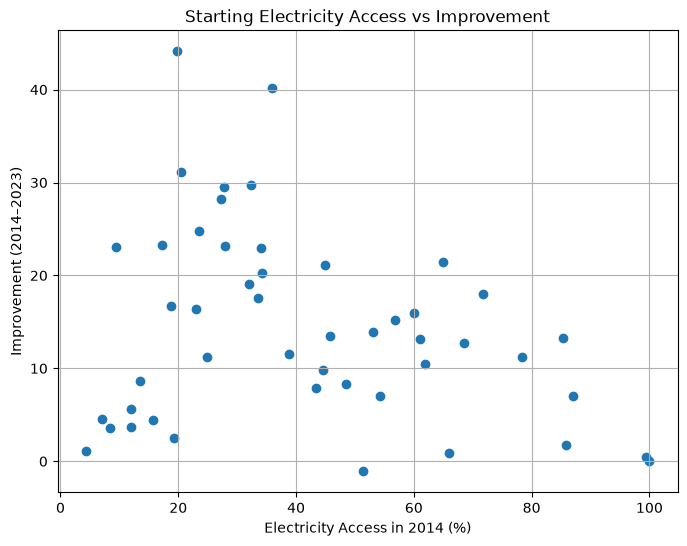

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(ssa_df["2014"], ssa_df["Improvement"])

plt.xlabel("Electricity Access in 2014 (%)")
plt.ylabel("Improvement (2014–2023)")
plt.title("Starting Electricity Access vs Improvement")

plt.grid(True)

plt.show()

In [54]:
ssa_df[["2014", "Improvement"]].corr()

,2014,Improvement
2014,1.000000,-0.269247
Improvement,-0.269247,1.000000


In [55]:
# Access_score is the normalized 2023 electricity electricity, we reverse it so that lower electricity access gets a higher score
ssa_df = calculate_access_score(ssa_df)

ssa_df[["Country Name", "2023", "Access_Score"]].head()

,Country Name,2023,Access_Score
4,Angola,51.1,0.516913
16,Burundi,11.6,0.934461
18,Benin,57.0,0.454545
19,Burkina Faso,21.7,0.827696
33,Botswana,76.0,0.253700


In [56]:
# Normalize Improvement
ssa_df = calculate_improvement_score(ssa_df)
ssa_df[["Country Name", "Improvement", "Improvement_Score"]].head()

,Country Name,Improvement,Improvement_Score
4,Angola,19.1,0.446903
16,Burundi,4.6,0.126106
18,Benin,22.9,0.530973
19,Burkina Faso,2.5,0.079646
33,Botswana,16.0,0.378319


In [57]:
ssa_df[ssa_df["Country Name"] == "Rwanda"][
    ["Country Name", "Improvement", "Improvement_Score"]
]

,Country Name,Improvement,Improvement_Score
202,Rwanda,44.1,1.0


In [58]:
# Calculate the priority score for equal weights
ssa_df = calculate_priority_score(
    ssa_df,
    access_weight=0.5,
    improvement_weight=0.5
)
# Show the top 10 countries
priority = (
    ssa_df[["Country Name", "2023", "Improvement", "Priority_Score"]]
    .sort_values("Priority_Score", ascending=False)
    .head(10)
)

priority

,Country Name,2023,Improvement,Priority_Score
202,Rwanda,63.9,44.1,0.690803
130,Liberia,32.5,23.1,0.624464
246,Uganda,51.5,31.1,0.612537
86,Guinea-Bissau,40.5,23.3,0.584394
120,Kenya,76.2,40.2,0.582651
140,Lesotho,57.3,29.5,0.564183
72,Ethiopia,55.4,28.2,0.559844
245,Tanzania,48.3,24.8,0.559760
264,Zimbabwe,62.0,29.7,0.541554
209,Sierra Leone,35.5,16.7,0.537812


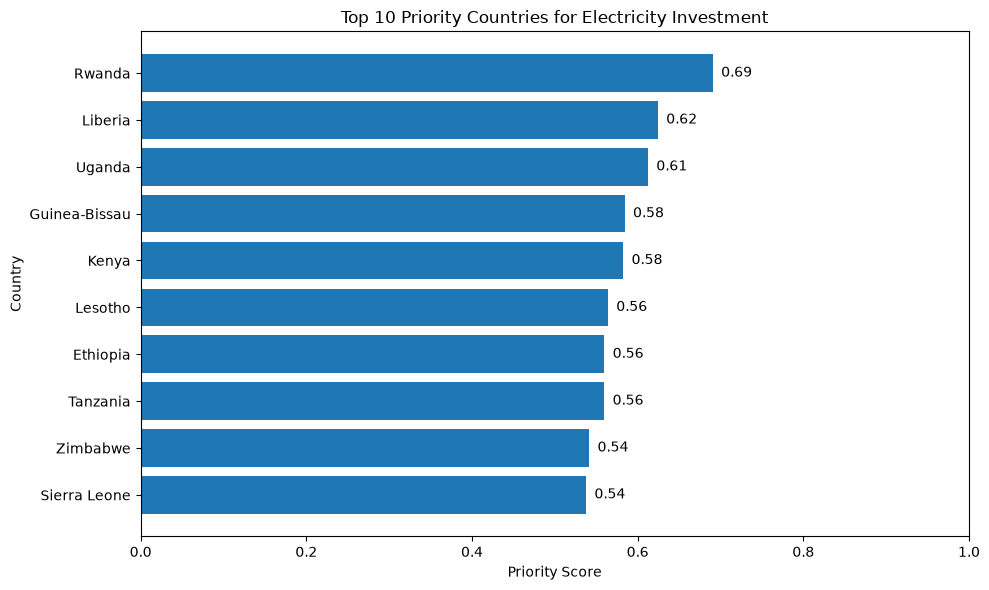

In [59]:
import matplotlib.pyplot as plt

# Prepare data
priority = (
    ssa_df[["Country Name", "Priority_Score"]]
    .sort_values("Priority_Score", ascending=False)
    .head(10)
)

# Create figure
plt.figure(figsize=(10, 6))

# Draw bars
bars = plt.barh(priority["Country Name"], priority["Priority_Score"])

# Put highest score at the top
plt.gca().invert_yaxis()

# Add score labels to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

# Titles
plt.title("Top 10 Priority Countries for Electricity Investment")
plt.xlabel("Priority Score")
plt.ylabel("Country")

# Limit x-axis for better spacing
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### Sensitivity Analysis

In [60]:
# New weights: 80% Access, 20% Improvement

ssa_df = calculate_priority_score(
    ssa_df,
    access_weight=0.8,
    improvement_weight=0.2,
    output_column="Priority_80_20"
)

# Top 10 countries
priority_80_20 = (
    ssa_df[
        [
            "Country Name",
            "2023",
            "Improvement",
            "Priority_80_20"
        ]
    ]
    .sort_values("Priority_80_20", ascending=False)
    .head(10)
)

priority_80_20

,Country Name,2023,Improvement,Priority_80_20
215,South Sudan,5.4,1.1,0.809735
16,Burundi,11.6,4.6,0.772790
228,Chad,12.0,3.6,0.764983
167,Malawi,15.6,3.7,0.734981
34,Central African Republic,17.6,5.6,0.726475
43,"Congo, Dem. Rep.",22.1,8.6,0.701694
172,Niger,20.1,4.4,0.700023
19,Burkina Faso,21.7,2.5,0.678086
130,Liberia,32.5,23.1,0.677904
209,Sierra Leone,35.5,16.7,0.624216


In [61]:
ssa_df[["Country Name", "Access_Score", "Improvement_Score", "Priority_Score"]].head(10)

,Country Name,Access_Score,Improvement_Score,Priority_Score
4,Angola,0.516913,0.446903,0.481908
16,Burundi,0.934461,0.126106,0.530284
18,Benin,0.454545,0.530973,0.492759
19,Burkina Faso,0.827696,0.079646,0.453671
33,Botswana,0.253700,0.378319,0.316009
34,Central African Republic,0.871036,0.148230,0.509633
41,Cote d'Ivoire,0.291755,0.256637,0.274196
42,Cameroon,0.295983,0.360619,0.328301
43,"Congo, Dem. Rep.",0.823467,0.214602,0.519035
44,"Congo, Rep.",0.514799,0.199115,0.356957


### Save Clean Dataset

In [62]:
ssa_df.to_csv(
    "../data/processed/ssa_electricity_clean_with_priority_score.csv",
    index=False
)

# Load population data
We want to know the total population without access to electricity, so we load and merge total population data to electricity access data from World bank database

In [63]:
population_df = load_worldbank_data(
    "../data/raw/population/API_SP.POP.TOTL_DS2_en_csv_v2_33112.csv"
)

In [64]:
# Number of rows and columns
print("Shape:", population_df.shape)


Shape: (265, 71)


In [65]:
# Column names
print("\nColumns:")
print(population_df.columns.tolist())


Columns:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [66]:
# Count missing values in each column
population_df.isna().sum()


Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960                2
                 ... 
2022                1
2023                1
2024                1
2025                1
Unnamed: 70       265
Length: 71, dtype: int64

In [67]:
# Display unique country names alphabetically
sorted(population_df["Country Name"].unique())

['Afghanistan',
 'Africa Eastern and Southern',
 'Africa Western and Central',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Caribbean small states',
 'Cayman Islands',
 'Central African Republic',
 'Central Europe and the Baltics',
 'Chad',
 'Channel Islands',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Early-demographic dividend',
 'East

In [68]:
# Merge the population data with the country metadata
population_df = merge_metadata(
    population_df,
    metadata
)

# Rename the 2023 column to Population_2023 for clarity
population_df.rename(
    columns={"2023": "Population_2023"},
    inplace=True
)


In [69]:

# Then filter SSA
ssapop_df = filter_ssa(population_df)

population_subset = ssapop_df[
    ["Country Code", "Population_2023"]
]

In [70]:
# Merge population data into the electricity dataframe
ssa_df = ssa_df.merge(
    population_subset,
    on="Country Code",
    how="left"
)

# Create the People_Without_Electricity column
ssa_df = calculate_people_without_electricity(ssa_df)

# Check the result
ssa_df[
    [
        "Country Name",
        "Population_2023",
        "2023",
        "People_Without_Electricity",
    ]
].head()

,Country Name,Population_2023,2023,People_Without_Electricity
0,Angola,36749906.0,51.1,1.797070e+07
1,Burundi,13689450.0,11.6,1.210147e+07
2,Benin,14111034.0,57.0,6.067745e+06
3,Burkina Faso,23025776.0,21.7,1.802918e+07
4,Botswana,2480244.0,76.0,5.952586e+05


In [71]:
# Normalize People_Without_Electricity within the SSA region to create a new score column

ssa_df = calculate_population_score(ssa_df) 

In [72]:

# call the Population-adjusted model with equal weights for access, improvement, and population
ssa_df = calculate_priority_score_with_population(
    ssa_df,
    access_weight=1/3,
    improvement_weight=1/3,
    population_weight=1/3,
)

In [73]:
priority = (
    ssa_df[
        [
            "Country Name",
            "2023",
            "Improvement",
            "People_Without_Electricity",
            "Population_Score",
            "Priority_Score"
        ]
    ]
    .sort_values("Priority_Score", ascending=False)
    .head(10)
)

priority

,Country Name,2023,Improvement,People_Without_Electricity,Population_Score,Priority_Score
8,"Congo, Dem. Rep.",22.1,8.6,8.241020e+07,0.932046,0.656705
13,Ethiopia,55.4,28.2,5.739649e+07,0.649145,0.589611
31,Nigeria,61.2,7.0,8.841858e+07,1.000000,0.529784
43,Tanzania,48.3,24.8,3.444130e+07,0.389526,0.503015
44,Uganda,51.5,31.1,2.359845e+07,0.266895,0.497323
32,Rwanda,63.9,44.1,5.037564e+06,0.056974,0.479527
20,Kenya,76.2,40.2,1.317068e+07,0.148958,0.438087
21,Liberia,32.5,23.1,3.707796e+06,0.041935,0.430288
23,Madagascar,39.4,16.4,1.890473e+07,0.213810,0.413857
41,Chad,12.0,3.6,1.700078e+07,0.192276,0.408830


Version 1 Summary

Objective

Develop a priority ranking model for Sub-Saharan African countries using electricity access, improvement in electricity access (2014–2023), and the estimated number of people without electricity.

Data Sources

World Bank: Access to Electricity
World Bank: Total Population

Methodology

Filter to SSA countries.
Calculate absolute improvement (2023 − 2014).
Normalize variables using min–max scaling.
Estimate people without electricity.
Build a weighted priority score.
Compare rankings before and after incorporating population.

Key Finding

Including population substantially changes the rankings, highlighting countries such as DR Congo and Nigeria because of the large number of people still lacking electricity.